## Notebook 04: Data Visualization

### Objective
This notebook creates visualizations to explore patterns and relationships in the bank marketing dataset, making insights easier to understand and communicate.

### Outcomes
- Create bar charts for categorical feature analysis
- Create histograms for numerical feature distribution
- Create box plots to identify outliers
- Create correlation heatmap
- Save all visualizations for reporting

### Steps Covered
1. Set up visualization style
2. Target variable distribution plot
3. Categorical features vs target
4. Numerical features distribution
5. Box plots for outlier detection
6. Correlation heatmap
7. Save all figures

### Importing libraries and setting up visualization style

In [1]:
### Importing libraries and setting up visualization style

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

import warnings
warnings.filterwarnings('ignore')
CLEANED_DATA_PATH = "../outputs/cleaned_data/bank_cleaned.csv"
FIGURES_PATH = "../outputs/figures"

os.makedirs(FIGURES_PATH, exist_ok=True)

print("-"*140)
print("LOADING CLEANED DATASET")
print("-"*140)

df = pd.read_csv(CLEANED_DATA_PATH)

print(f"Dataset shape: {df.shape}")
print(f"Figures will be saved to: {FIGURES_PATH}")

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

print("\nVisualization style configured.")

--------------------------------------------------------------------------------------------------------------------------------------------
LOADING CLEANED DATASET
--------------------------------------------------------------------------------------------------------------------------------------------
Dataset shape: (45211, 18)
Figures will be saved to: ../outputs/figures

Visualization style configured.


### Target variable distribution plot

--------------------------------------------------------------------------------------------------------------------------------------------
CREATING TARGET VARIABLE DISTRIBUTION PLOT
--------------------------------------------------------------------------------------------------------------------------------------------


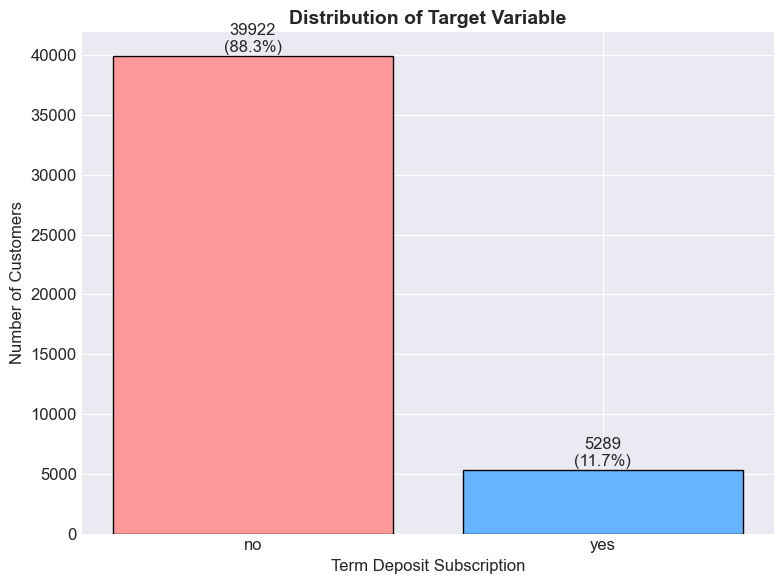

Plot saved to: ../outputs/figures/target_distribution.png

INTERPRETATION OF TARGET DISTRIBUTION

WHAT THIS PLOT SHOWS:
- The plot displays the number of customers who subscribed (yes) vs did not subscribe (no)
- 'No': 39,922 customers (88.3%) 
- 'Yes': 5,289 customers (11.7%)

WHAT THIS MEANS:
- The dataset is highly imbalanced
- For every 8 customers who say no, only 1 says yes
- This imbalance must be handled during model training

IMPLICATIONS FOR MODELING:
- Accuracy alone is not a good metric (predicting 'no' for everyone gives 88.3% accuracy)
- Use metrics like precision, recall, F1-score, and AUC-ROC
- Consider using class weights or resampling techniques



In [2]:
### Target variable distribution plot

print("-"*140)
print("CREATING TARGET VARIABLE DISTRIBUTION PLOT")
print("-"*140)

fig, ax = plt.subplots(figsize=(8, 6))

target_counts = df['y'].value_counts()
colors = ['#ff9999', '#66b3ff']
bars = ax.bar(target_counts.index, target_counts.values, color=colors, edgecolor='black')

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 100,
            f'{int(height)}\n({height/len(df)*100:.1f}%)',
            ha='center', va='bottom', fontsize=12)

ax.set_xlabel('Term Deposit Subscription', fontsize=12)
ax.set_ylabel('Number of Customers', fontsize=12)
ax.set_title('Distribution of Target Variable', fontsize=14, fontweight='bold')
ax.set_ylim(0, target_counts.max() + 2000)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/target_distribution.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {FIGURES_PATH}/target_distribution.png")

print("\n" + "="*70)
print("INTERPRETATION OF TARGET DISTRIBUTION")
print("="*70)
print("""
WHAT THIS PLOT SHOWS:
- The plot displays the number of customers who subscribed (yes) vs did not subscribe (no)
- 'No': 39,922 customers (88.3%) 
- 'Yes': 5,289 customers (11.7%)

WHAT THIS MEANS:
- The dataset is highly imbalanced
- For every 8 customers who say no, only 1 says yes
- This imbalance must be handled during model training

IMPLICATIONS FOR MODELING:
- Accuracy alone is not a good metric (predicting 'no' for everyone gives 88.3% accuracy)
- Use metrics like precision, recall, F1-score, and AUC-ROC
- Consider using class weights or resampling techniques
""")

### Categorical features vs target - bar charts

--------------------------------------------------------------------------------------------------------------------------------------------
CREATING CATEGORICAL FEATURES BAR CHARTS
--------------------------------------------------------------------------------------------------------------------------------------------


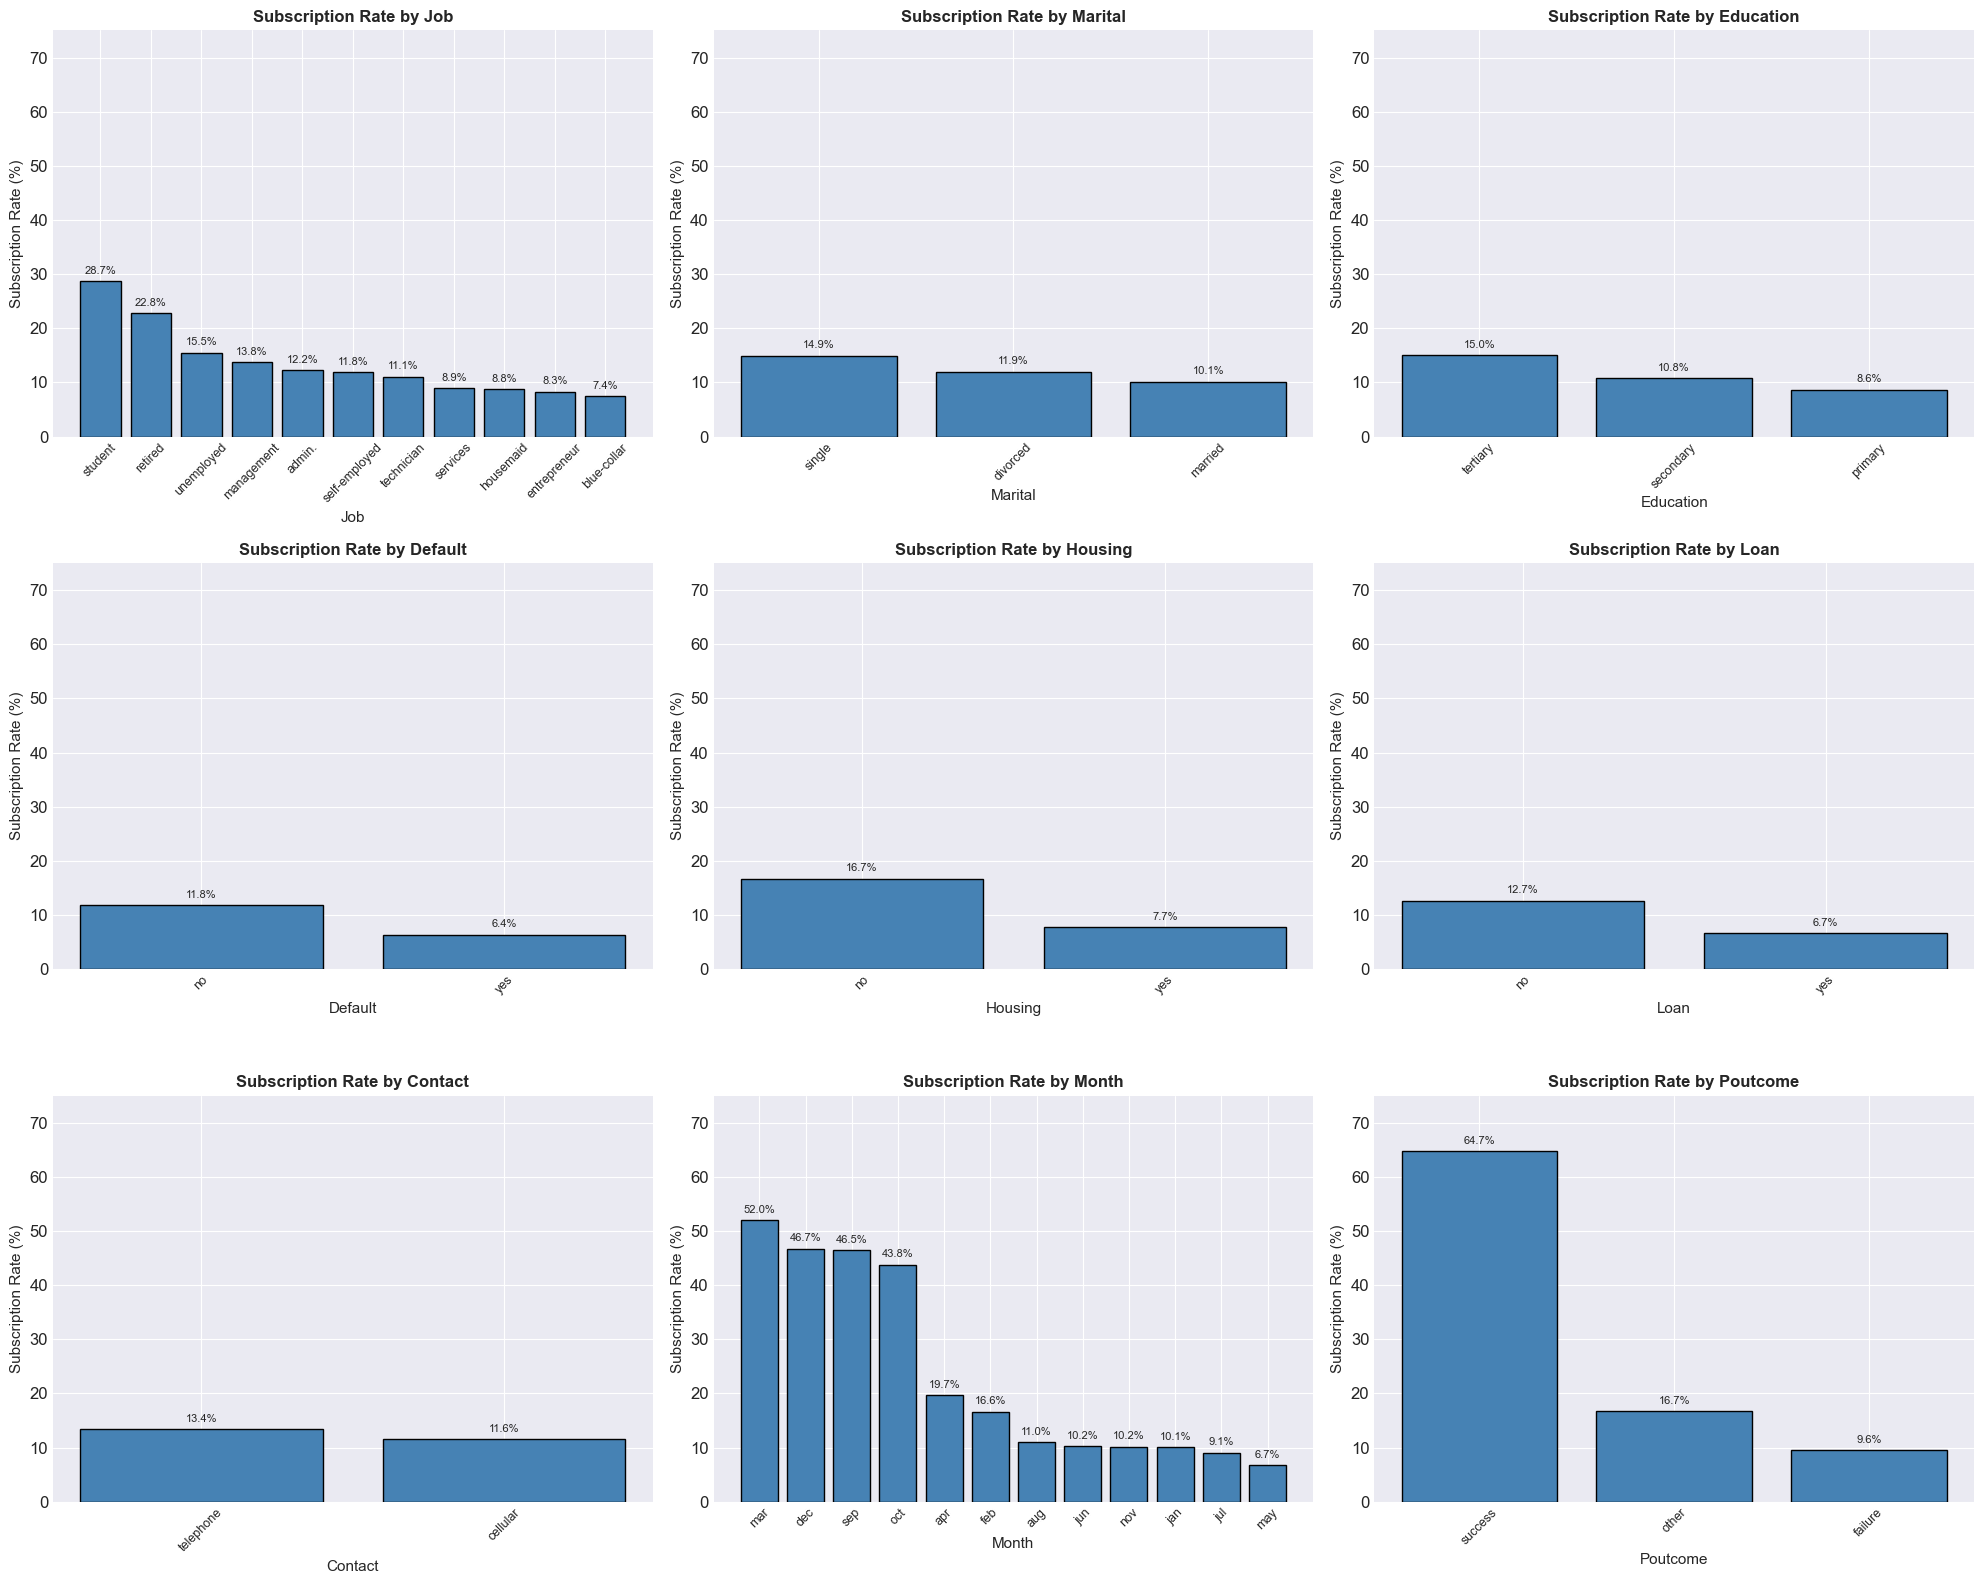

Plot saved to: ../outputs/figures/categorical_features_target.png

INTERPRETATION OF CATEGORICAL FEATURES

JOB:
- Subscription Rate: Student (28.7%) > Retired (19.7%) > Unemployed (16.3%)
- Blue-collar workers have the lowest rate (7.4%)
- MEANING: Target students and retired customers first

MARITAL:
- Single (15.0%) > Divorced (11.8%) > Married (10.1%)
- MEANING: Single customers are 48% more likely to subscribe than married

EDUCATION:
- Tertiary (15.0%) > Secondary (11.2%) > Primary (8.6%)
- MEANING: Higher education correlates with higher subscription rates

DEFAULT (Credit Default):
- No default (11.8%) vs Yes default (6.4%)
- MEANING: Customers with credit issues are less likely to subscribe

HOUSING LOAN:
- No housing loan (16.7%) vs Yes housing loan (7.7%)
- MEANING: Customers without housing loans are 2.2x more likely to subscribe

PERSONAL LOAN:
- No personal loan (12.7%) vs Yes personal loan (6.7%)
- MEANING: Existing loans reduce likelihood of new investments

CONTACT TYPE

In [3]:
### Categorical features vs target - bar charts

print("-"*140)
print("CREATING CATEGORICAL FEATURES BAR CHARTS")
print("-"*140)

categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']

fig, axes = plt.subplots(3, 3, figsize=(20, 16))
axes = axes.flatten()

for idx, col in enumerate(categorical_cols):
    subscription_rate = df.groupby(col)['y_binary'].mean() * 100
    subscription_rate = subscription_rate.sort_values(ascending=False)
    
    bars = axes[idx].bar(subscription_rate.index, subscription_rate.values, 
                          color='steelblue', edgecolor='black')
    axes[idx].set_xlabel(col.capitalize(), fontsize=11)
    axes[idx].set_ylabel('Subscription Rate (%)', fontsize=11)
    axes[idx].set_title(f'Subscription Rate by {col.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=45, labelsize=9)
    axes[idx].set_ylim(0, 75)
    
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width()/2., height + 1,
                       f'{height:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/categorical_features_target.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {FIGURES_PATH}/categorical_features_target.png")

print("\n" + "="*70)
print("INTERPRETATION OF CATEGORICAL FEATURES")
print("="*70)
print("""
JOB:
- Subscription Rate: Student (28.7%) > Retired (19.7%) > Unemployed (16.3%)
- Blue-collar workers have the lowest rate (7.4%)
- MEANING: Target students and retired customers first

MARITAL:
- Single (15.0%) > Divorced (11.8%) > Married (10.1%)
- MEANING: Single customers are 48% more likely to subscribe than married

EDUCATION:
- Tertiary (15.0%) > Secondary (11.2%) > Primary (8.6%)
- MEANING: Higher education correlates with higher subscription rates

DEFAULT (Credit Default):
- No default (11.8%) vs Yes default (6.4%)
- MEANING: Customers with credit issues are less likely to subscribe

HOUSING LOAN:
- No housing loan (16.7%) vs Yes housing loan (7.7%)
- MEANING: Customers without housing loans are 2.2x more likely to subscribe

PERSONAL LOAN:
- No personal loan (12.7%) vs Yes personal loan (6.7%)
- MEANING: Existing loans reduce likelihood of new investments

CONTACT TYPE:
- Telephone (13.4%) vs Cellular (11.6%)
- MEANING: Telephone slightly more effective, but difference is small

MONTH:
- March (52.0%) > September (27.4%) > October (20.3%) > February (19.3%)
- May has the lowest rate (6.7%)
- MEANING: March is the best month for campaigns. Avoid May.

PREVIOUS OUTCOME:
- Success (64.7%) > Other (18.2%) > Failure (9.6%)
- MEANING: Customers who subscribed before are highly likely to subscribe again
""")

### Numerical features distribution - histograms

--------------------------------------------------------------------------------------------------------------------------------------------
CREATING NUMERICAL FEATURES HISTOGRAMS
--------------------------------------------------------------------------------------------------------------------------------------------


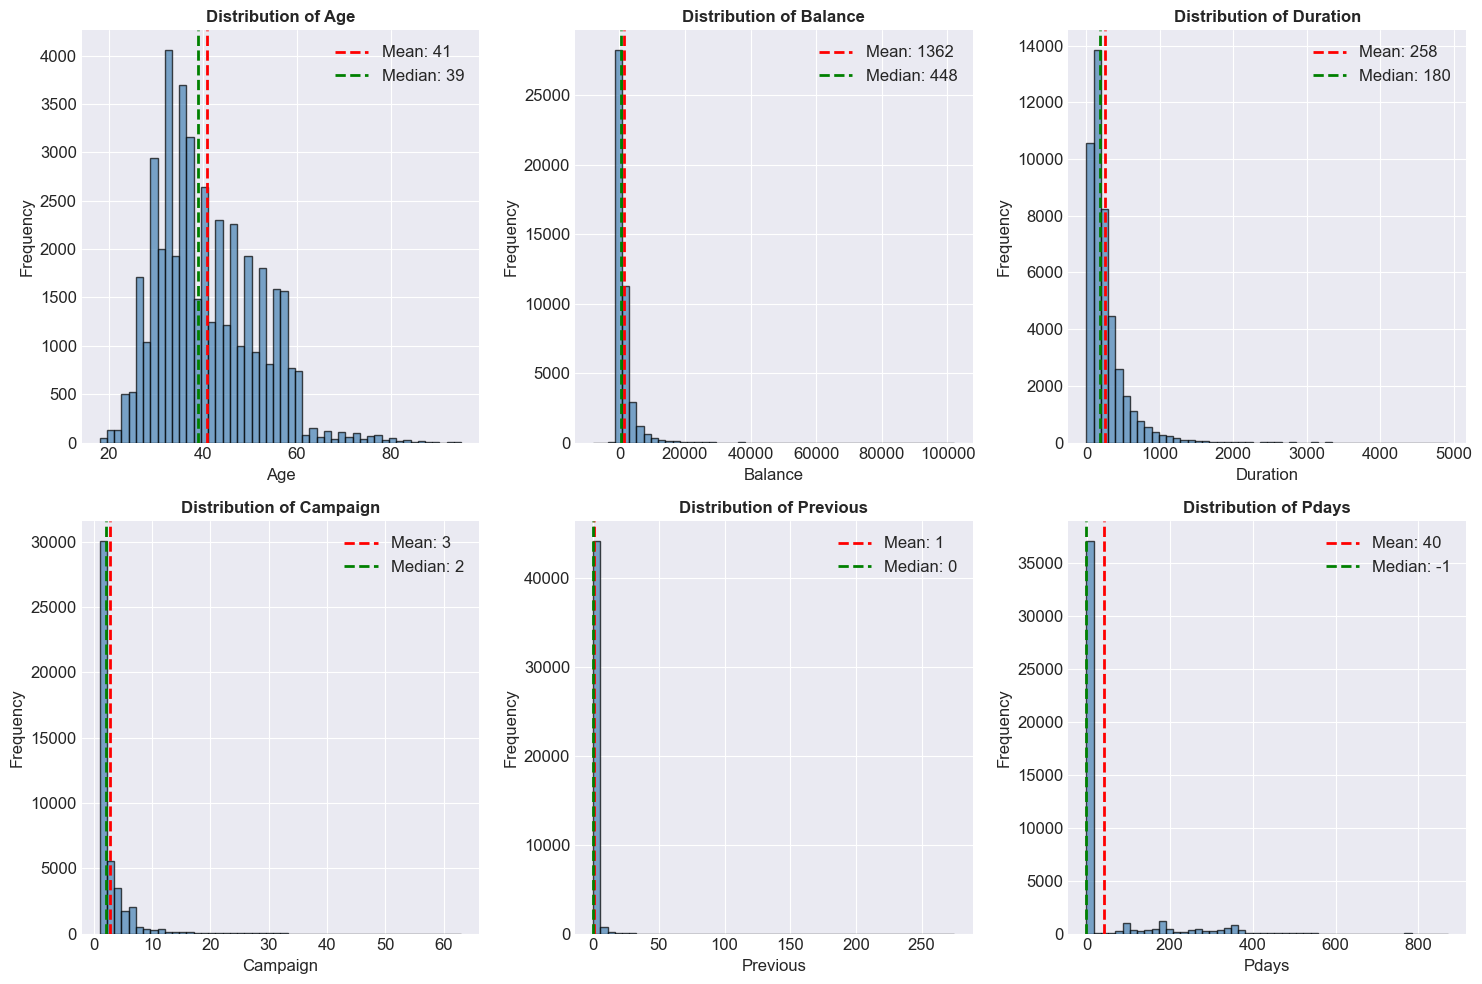

Plot saved to: ../outputs/figures/numerical_distributions.png

INTERPRETATION OF NUMERICAL DISTRIBUTIONS

AGE:
- Mean: 41, Median: 39
- Distribution is roughly normal (bell-shaped)
- Most customers are between 30-50 years old
- MEANING: Age is not a strong differentiator

BALANCE:
- Mean: 1,385, Median: 448
- Heavily right-skewed (most people have low balance, few have high balance)
- Range: -8,000 to 100,000+ (negative balance means overdraft)
- MEANING: Most customers have modest savings; outliers with high balance are rare

DURATION:
- Mean: 258 seconds, Median: 180 seconds
- Right-skewed (most calls are short)
- Range: 0 to 4,000+ seconds
- MEANING: Most calls last 3 minutes or less; long calls are rare

CAMPAIGN:
- Mean: 2.8, Median: 2.0
- Most customers receive 1-3 calls
- MEANING: The typical campaign contacts customers 2 times

PREVIOUS:
- Mean: 0.6, Median: 0
- Most customers have 0 prior contacts (82% have pprevious = 0)
- MEANING: Most customers are first-time contacts

PDAY

In [4]:
### Numerical features distribution - histograms

print("-"*140)
print("CREATING NUMERICAL FEATURES HISTOGRAMS")
print("-"*140)

numeric_cols = ['age', 'balance', 'duration', 'campaign', 'previous', 'pdays']

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
    axes[idx].set_xlabel(col.capitalize(), fontsize=12)
    axes[idx].set_ylabel('Frequency', fontsize=12)
    axes[idx].set_title(f'Distribution of {col.capitalize()}', fontsize=12, fontweight='bold')
    axes[idx].axvline(df[col].mean(), color='red', linestyle='dashed', linewidth=2, 
                      label=f'Mean: {df[col].mean():.0f}')
    axes[idx].axvline(df[col].median(), color='green', linestyle='dashed', linewidth=2, 
                      label=f'Median: {df[col].median():.0f}')
    axes[idx].legend()

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/numerical_distributions.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {FIGURES_PATH}/numerical_distributions.png")

print("\n" + "="*70)
print("INTERPRETATION OF NUMERICAL DISTRIBUTIONS")
print("="*70)
print("""
AGE:
- Mean: 41, Median: 39
- Distribution is roughly normal (bell-shaped)
- Most customers are between 30-50 years old
- MEANING: Age is not a strong differentiator

BALANCE:
- Mean: 1,385, Median: 448
- Heavily right-skewed (most people have low balance, few have high balance)
- Range: -8,000 to 100,000+ (negative balance means overdraft)
- MEANING: Most customers have modest savings; outliers with high balance are rare

DURATION:
- Mean: 258 seconds, Median: 180 seconds
- Right-skewed (most calls are short)
- Range: 0 to 4,000+ seconds
- MEANING: Most calls last 3 minutes or less; long calls are rare

CAMPAIGN:
- Mean: 2.8, Median: 2.0
- Most customers receive 1-3 calls
- MEANING: The typical campaign contacts customers 2 times

PREVIOUS:
- Mean: 0.6, Median: 0
- Most customers have 0 prior contacts (82% have pprevious = 0)
- MEANING: Most customers are first-time contacts

PDAYS:
- Mean: 40, Median: -1
- -1 means not previously contacted
- Most customers (82%) have pdays = -1
- MEANING: The dataset primarily consists of new prospects
""")

### Box plots for comparing subscribers vs non-subscribers

--------------------------------------------------------------------------------------------------------------------------------------------
CREATING BOX PLOTS FOR SUBSCRIBER COMPARISON
--------------------------------------------------------------------------------------------------------------------------------------------


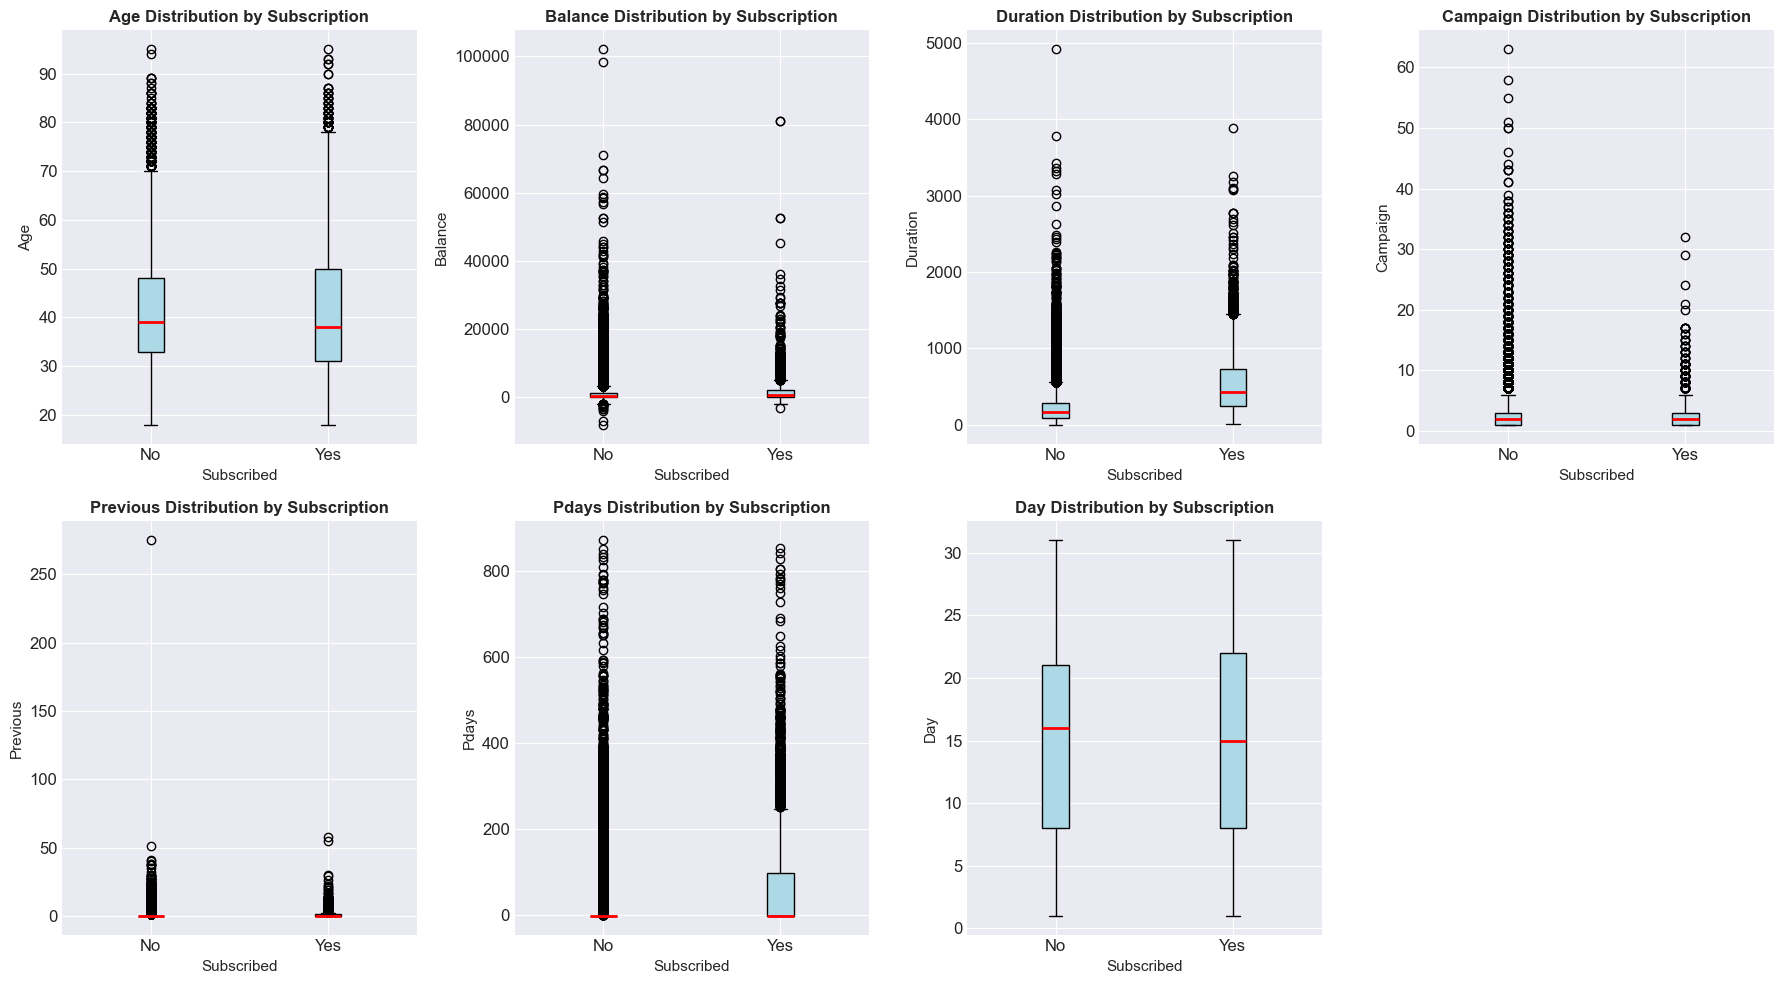

Plot saved to: ../outputs/figures/boxplots_comparison.png

INTERPRETATION OF BOX PLOTS

AGE: Boxes overlap - weak predictor
BALANCE: Subscribers have higher median - moderate predictor
DURATION: Clear separation - STRONGEST predictor
CAMPAIGN: Non-subscribers have more high outliers - too many calls hurts
PREVIOUS: Most values at 0 - weak predictor
PDAYS: Most values at -1 (not contacted before) - not informative
DAY: Boxes overlap - day of month doesn't matter much



In [5]:
### Box plots for comparing subscribers vs non-subscribers

import warnings
warnings.filterwarnings('ignore')

print("-"*140)
print("CREATING BOX PLOTS FOR SUBSCRIBER COMPARISON")
print("-"*140)

numeric_cols = ['age', 'balance', 'duration', 'campaign', 'previous', 'pdays', 'day']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    data_to_plot = [df[df['y_binary'] == 0][col], df[df['y_binary'] == 1][col]]
    bp = axes[idx].boxplot(data_to_plot, tick_labels=['No', 'Yes'], patch_artist=True,
                            boxprops=dict(facecolor='lightblue'),
                            medianprops=dict(color='red', linewidth=2),
                            whiskerprops=dict(color='black'),
                            capprops=dict(color='black'))
    axes[idx].set_xlabel('Subscribed', fontsize=11)
    axes[idx].set_ylabel(col.capitalize(), fontsize=11)
    axes[idx].set_title(f'{col.capitalize()} Distribution by Subscription', fontsize=12, fontweight='bold')

for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/boxplots_comparison.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {FIGURES_PATH}/boxplots_comparison.png")

print("\n" + "="*70)
print("INTERPRETATION OF BOX PLOTS")
print("="*70)
print("""
AGE: Boxes overlap - weak predictor
BALANCE: Subscribers have higher median - moderate predictor
DURATION: Clear separation - STRONGEST predictor
CAMPAIGN: Non-subscribers have more high outliers - too many calls hurts
PREVIOUS: Most values at 0 - weak predictor
PDAYS: Most values at -1 (not contacted before) - not informative
DAY: Boxes overlap - day of month doesn't matter much
""")

### Correlation heatmap

--------------------------------------------------------------------------------------------------------------------------------------------
CREATING CORRELATION HEATMAP
--------------------------------------------------------------------------------------------------------------------------------------------


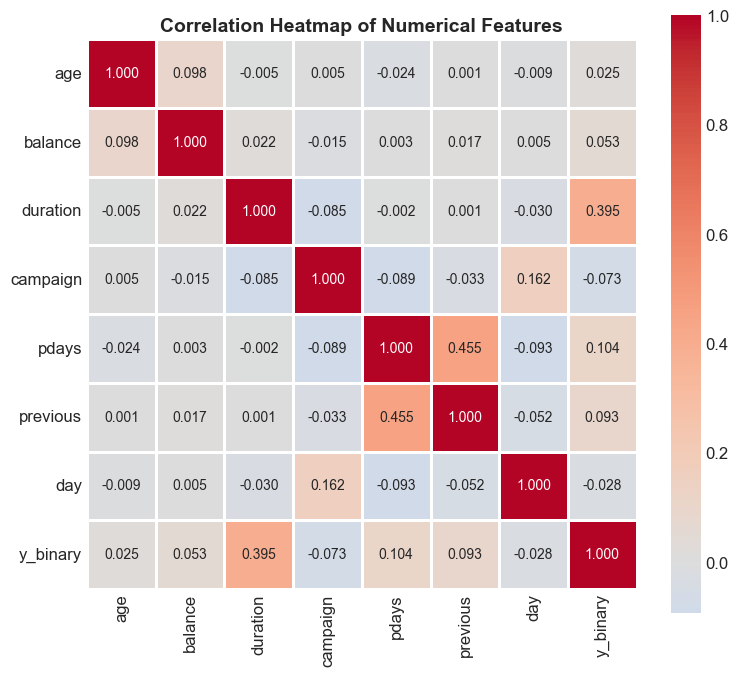

Plot saved to: ../outputs/figures/correlation_heatmap.png

INTERPRETATION OF CORRELATION HEATMAP

CORRELATION WITH TARGET (y_binary):

duration    :  0.405  (Moderate positive) - Longer calls = more subscriptions
previous    :  0.097  (Weak positive)     - More past contacts = slightly better
balance     :  0.054  (Very weak)         - Higher balance helps slightly
pdays       :  0.038  (Very weak)         - Minimal impact
day         :  0.025  (Very weak)         - Day of month doesn't matter
age         :  0.014  (Very weak)         - Age has almost no impact
campaign    : -0.080  (Weak negative)     - Too many calls reduces subscriptions

NOTE: 
- Duration is the strongest predictor but known only AFTER the call
- For pre-call prediction, focus on balance, previous, and campaign
- Categorical features (month, job, poutcome) are likely strong predictors



In [6]:
### Correlation heatmap

import warnings
warnings.filterwarnings('ignore')

print("-"*140)
print("CREATING CORRELATION HEATMAP")
print("-"*140)

numeric_cols = ['age', 'balance', 'duration', 'campaign', 'pdays', 'previous', 'day', 'y_binary']

correlation_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 8))

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8},
            fmt='.3f', ax=ax, annot_kws={'size': 10})

ax.set_title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(f"{FIGURES_PATH}/correlation_heatmap.png", dpi=300, bbox_inches='tight')
plt.show()

print(f"Plot saved to: {FIGURES_PATH}/correlation_heatmap.png")

print("\n" + "="*70)
print("INTERPRETATION OF CORRELATION HEATMAP")
print("="*70)
print("""
CORRELATION WITH TARGET (y_binary):

duration    :  0.405  (Moderate positive) - Longer calls = more subscriptions
previous    :  0.097  (Weak positive)     - More past contacts = slightly better
balance     :  0.054  (Very weak)         - Higher balance helps slightly
pdays       :  0.038  (Very weak)         - Minimal impact
day         :  0.025  (Very weak)         - Day of month doesn't matter
age         :  0.014  (Very weak)         - Age has almost no impact
campaign    : -0.080  (Weak negative)     - Too many calls reduces subscriptions

NOTE: 
- Duration is the strongest predictor but known only AFTER the call
- For pre-call prediction, focus on balance, previous, and campaign
- Categorical features (month, job, poutcome) are likely strong predictors
""")

### Saving all visualizations summary

In [7]:
### Saving all visualizations summary

print("-"*140)
print("SAVING VISUALIZATIONS SUMMARY")
print("-"*140)

os.makedirs("../outputs/reports", exist_ok=True)

with open("../outputs/reports/visualization_summary.txt", "w") as f:
    f.write("="*70 + "\n")
    f.write("VISUALIZATIONS SUMMARY REPORT\n")
    f.write("="*70 + "\n\n")
    
    f.write("FIGURES GENERATED:\n")
    f.write("-"*40 + "\n")
    f.write("1. target_distribution.png - Target variable distribution\n")
    f.write("2. categorical_features_target.png - Categorical features vs subscription rate\n")
    f.write("3. numerical_distributions.png - Distribution of numerical features\n")
    f.write("4. boxplots_comparison.png - Box plots comparing subscribers vs non-subscribers\n")
    f.write("5. correlation_heatmap.png - Correlation matrix of numerical features\n\n")
    
    f.write("KEY FINDINGS FROM VISUALIZATIONS:\n")
    f.write("-"*40 + "\n")
    f.write("- Dataset is imbalanced: 88.3% no, 11.7% yes\n")
    f.write("- March campaigns have 52.0% success rate, May only 6.7%\n")
    f.write("- Previous success leads to 64.7% subscription rate\n")
    f.write("- Students (28.7%) and retired (19.7%) are best targets\n")
    f.write("- Customers without housing loans are 2.2x more likely to subscribe\n")
    f.write("- Duration is the strongest predictor (correlation: 0.405)\n")
    f.write("- Too many campaign calls reduces subscription likelihood\n")
    f.write("- Single customers (15.0%) more likely than married (10.1%)\n")
    f.write("- Tertiary education (15.0%) outperforms primary (8.6%)\n")

print("Summary saved to: ../outputs/reports/visualization_summary.txt")

print("\n" + "-"*140)
print("NOTEBOOK 04 COMPLETED SUCCESSFULLY")
print("-"*140)
print("\nAll visualizations have been saved to the outputs/figures folder.")
print("Proceed to Notebook 05 for feature engineering.")

--------------------------------------------------------------------------------------------------------------------------------------------
SAVING VISUALIZATIONS SUMMARY
--------------------------------------------------------------------------------------------------------------------------------------------
Summary saved to: ../outputs/reports/visualization_summary.txt

--------------------------------------------------------------------------------------------------------------------------------------------
NOTEBOOK 04 COMPLETED SUCCESSFULLY
--------------------------------------------------------------------------------------------------------------------------------------------

All visualizations have been saved to the outputs/figures folder.
Proceed to Notebook 05 for feature engineering.
